# Name : Bansi Ajagia
# **Subject** : Machine Learning
# **Project** : Cardiovascular Disease Prediction System

---

# Task 3 — Model Creation

## 📥 Prepare Data

In [1]:
# Name : Bansi Ajagia
# Subject : Machine Learning
# Project : Cardiovascular Disease Prediction System

import pandas as pd
import numpy as np
import pickle, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cardio.csv', sep=';')
df['age_years'] = (df['age'] / 365).round(0).astype(int)
df = df[df['ap_hi'].between(60,250)]
df = df[df['ap_lo'].between(40,200)]
df = df[df['height'].between(100,250)]
df = df[df['weight'].between(30,250)]

FEATURE_COLS = ['age_years','gender','height','weight',
                'ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']
X = df[FEATURE_COLS].values
y = df['cardio'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Data ready.')

Data ready.


## 1️⃣ Logistic Regression (Library)

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))
print(f'Logistic Regression Accuracy: {lr_acc:.4f}')

Logistic Regression Accuracy: 0.7224


## 2️⃣ Random Forest (Library)

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f'Random Forest Accuracy: {rf_acc:.4f}')

Random Forest Accuracy: 0.7018


## 3️⃣ Manual Rule-Based Classifier (No Library)

This implements a threshold-based rule without sklearn:

In [11]:
class RuleBasedClassifier:
    """
    Manual algorithm — no ML library used.
    Flags risk if: systolic BP >= 140  OR  cholesterol == 3  OR  age >= 55
    """
    def predict(self, X):
        age   = X[:, 0]   # age_years
        ap_hi = X[:, 4]   # systolic BP
        chol  = X[:, 6]   # cholesterol level
        return ((ap_hi >= 140) | (chol == 3) | (age >= 55)).astype(int)

rb = RuleBasedClassifier()
rb_acc = accuracy_score(y_test, rb.predict(X_test))
print(f'Rule-Based Accuracy: {rb_acc:.4f}')

Rule-Based Accuracy: 0.6937


## 4️⃣ Model Comparison

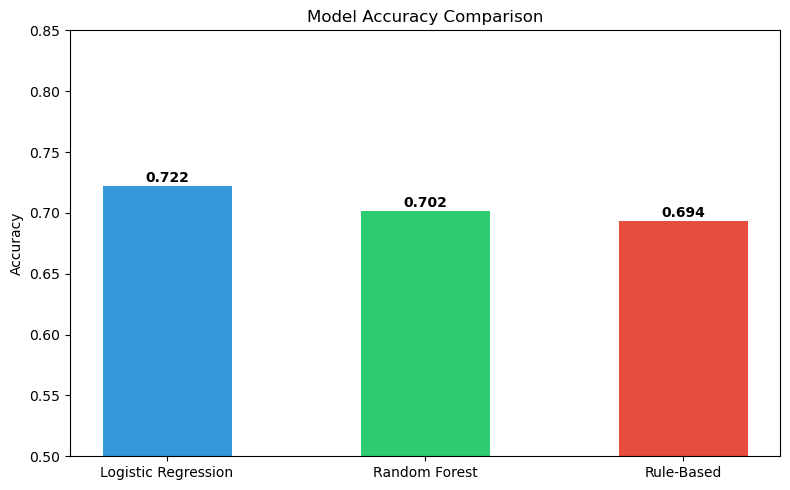

In [14]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'Rule-Based']
accuracies = [lr_acc, rf_acc, rb_acc]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(models, accuracies, color=['#3498db','#2ecc71','#e74c3c'], width=0.5)
ax.set_ylim(0.5, 0.85)
ax.set_title('Model Accuracy Comparison')
ax.set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{acc:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=120)
plt.show()

## 5️⃣ Save Best Model

In [16]:
os.makedirs('../models', exist_ok=True)
best_acc = max(lr_acc, rf_acc)
best_model  = lr if lr_acc >= rf_acc else rf
best_scaler = scaler if lr_acc >= rf_acc else None
best_name   = 'Logistic Regression' if lr_acc >= rf_acc else 'Random Forest'

bundle = {'model': best_model, 'scaler': best_scaler, 'model_name': best_name}
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f'Saved best model: {best_name} (accuracy={best_acc:.4f})')

Saved best model: Logistic Regression (accuracy=0.7224)
